## NYC Yellow Taxi Operations Intelligence: An Exploratory Data Analysis of Urban Mobility (May 2026)

### 1. Executive Summary
This project analyzes May 2026 NYC Yellow Taxi trips to understand demand patterns, revenue drivers, customer behavior, and operational efficiency. Using Python, SQL, and Tableau, the analysis identifies peak operating periods, profitable locations, airport demand, customer payment behavior, and opportunities to improve fleet allocation.

### 2. Business Problem
NYC Taxi operators generate millions of trips every month. Understanding demand, pricing, passenger behavior, and operational efficiency can improve fleet utilization, increase revenue, reduce idle time, and enhance customer experience.

### 3. Business Objectives
Identify peak demand periods, understand revenue drivers, analyze passenger behavior, evaluate operational efficiency, identify high-performing zones and support data-driven operational decisions.

In [1]:
# SECTION 1: IMPORT LIBRARIES & GLOBAL SETTINGS

import warnings
from datetime import datetime


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

warnings.filterwarnings("ignore")

# Global Visual Settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.autolayout"] = True
plt.rcParams['figure.figsize'] = (10,8)

In [2]:
# ==============================================================================
# SECTION 2: LOAD DATA
# ==============================================================================
parquet_file = r"C:\Users\hp\Desktop\Dataset\yellow_tripdata_2026-05.parquet"
zones_file = r"C:\Users\hp\Desktop\Dataset\taxi_zone_lookup.csv"

trips = pd.read_parquet(parquet_file)
zones = pd.read_csv(zones_file)

# Raw Copies for Audit Trail
raw_trips = trips.copy()
raw_zones = zones.copy()

# Basic inspection 
print("\n Initial Data Overview:")
print("="*30)

# 1 Tables Shape
print(f"Trips shape: {trips.shape}")
print(f"Zones shape: {zones.shape}")

# 2 Column data types
print("\n🔹 Column Data Types (Trips):")
print(trips.dtypes)
print("\n🔹 Column Data Types (Zones):")
print(zones.dtypes)

# 3 Missing values
print("\n🔹 Missing Values (Trips):")
print(trips.isna().sum())
print("\n🔹 Missing Values (Zones):")
print(zones.isna().sum())


 Initial Data Overview:
Trips shape: (4090836, 20)
Zones shape: (265, 4)

🔹 Column Data Types (Trips):
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

🔹 Column Data Types (Zones):
LocationID       int64
Borough         object
Zone  

In [3]:
# View the specific rows with missing values

zones_nulls = zones[zones.isna().any(axis=1)]
print(zones_nulls)

     LocationID  Borough            Zone service_zone
263         264  Unknown             NaN          NaN
264         265      NaN  Outside of NYC          NaN


In [4]:
# Statistical summary for the trip data

trips.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,4090836.0,1.873889,1.0,2.0,2.0,2.0,7.0,0.726003
tpep_pickup_datetime,4090836,2026-05-16 10:34:13.127794,2008-12-31 23:05:53,2026-05-08 21:15:44.750000,2026-05-16 01:47:51,2026-05-23 15:40:14.250000,2026-06-01 00:20:35,NaN
tpep_dropoff_datetime,4090836,2026-05-16 10:52:59.680849,2009-01-01 17:08:07,2026-05-08 21:32:40.500000,2026-05-16 02:03:14.500000,2026-05-23 15:57:52.250000,2026-06-02 12:53:42,NaN
passenger_count,3135465.0,1.24326,0.0,1.0,1.0,1.0,9.0,0.636677
trip_distance,4090836.0,4.954773,0.0,1.04,1.87,3.81,307491.47,483.615666
RatecodeID,3135465.0,5.495495,1.0,1.0,1.0,1.0,99.0,20.28825
PULocationID,4090836.0,162.104693,1.0,114.0,161.0,234.0,265.0,67.002973
DOLocationID,4090836.0,161.832636,1.0,108.0,162.0,234.0,265.0,70.709122
payment_type,4090836.0,0.880334,0.0,1.0,1.0,1.0,4.0,0.610464
fare_amount,4090836.0,21.513197,-950.0,10.0,16.3,26.8,5525.99,19.013032


### Key Observations:
#### 1. Overview & Data Completeness
* Total Records: 4,090,836 rows (indicated by count for VendorID).

* Missing Values (NaNs): passenger_count, RatecodeID, congestion_surcharge, and Airport_fee only have 3,135,465 non-null rows (~23.4% missing).
- Insight: Around 955,000 trips were recorded by vendors or mechanisms that do not capture passenger counts or specific surcharges (often associated with certain dispatch systems or taxi app providers).

#### 2. Data Anomalies & Data Cleaning Flags

* a) Date & Time Outliers: Min Pickup: 2008-12-31 23:05:53; Max Pickup: 2026-06-01 00:20:35
- Issue: The dataset is for May 2026. Trips back in 2008 indicate corrupt clock data from taxi meters and need to be filtered out (tpep_pickup_datetime between 2026-05-01 and 2026-05-31).

* b) Negative Fares & Credits: Min Fare Amount: -$950.00; Min Total Amount: -$951.00
- Issue: Negative values represent trip disputes, system corrections, or chargebacks. These should either be filtered out or isolated for dispute analysis.

* c) Impossible Distances & Fares: Max Distance: 307,491.5 miles (more than the distance to the Moon); Max Fare:$5,525.99
- Issue: Extreme outliers caused by GPS sensor glitches or manual override errors.

* d) Zero Values: Min Passenger Count: 0.0 (indicates driver didn't input passengers or automated log).
Min Trip Distance: 0.0 miles (represents cancelled trips, immediate drop-offs, or meter errors).

* Skewness: Distance, Fare, and Total Amount are strongly right-skewed. Median values ($16.30 fare, 1.87 miles) describe typical trip patterns far better than means ($21.51 fare, 4.95 miles)

In [5]:
# ==============================================================================
# SECTION 3: DATA CLEANING
# ==============================================================================
# 3.1 Clean Zones
# Handle specific missing entries for LocationIDs 264 & 265
zones.loc[zones['LocationID'] == 264, ['Zone', 'service_zone']] = ['NV / Unknown', 'Unknown']
zones.loc[zones['LocationID'] == 265, ['Borough', 'service_zone']] = ['Outside NYC', 'Outside NYC']

# General fallback fill (safety check)
zones['Borough'] = zones['Borough'].fillna('Unknown')
zones['Zone'] = zones['Zone'].fillna('Unknown')
zones['service_zone'] = zones['service_zone'].fillna('Unknown')

print("Remaining Missing Values:")
print(zones.isnull().sum())

Remaining Missing Values:
LocationID      0
Borough         0
Zone            0
service_zone    0
dtype: int64


In [6]:
# ==============================================================================
# SECTION 3: DATA CLEANING
# ==============================================================================

# 3.2 Clean Trips
df = trips[
    (trips["tpep_pickup_datetime"] >= "2026-05-01")
    & (trips["tpep_pickup_datetime"] < "2026-06-01")
    & (trips["fare_amount"] > 0)
    & (trips["fare_amount"] <= 500)
    & (trips["trip_distance"] > 0)
    & (trips["trip_distance"] <= 100)
    & (trips['passenger_count'] > 0)
]

# 3.3 Merge Geographic Metadata
df = df.merge(
    zones.add_prefix("pickup_"),
    left_on="PULocationID",
    right_on="pickup_LocationID",
    how="left",
).drop(columns=["pickup_LocationID"])

df = df.merge(
    zones.add_prefix("dropoff_"),
    left_on="DOLocationID",
    right_on="dropoff_LocationID",
    how="left",
).drop(columns=["dropoff_LocationID"])


# Inspect the trip data after cleaning
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_Borough,pickup_Zone,pickup_service_zone,dropoff_Borough,dropoff_Zone,dropoff_service_zone
0,2,2026-05-01 00:04:59,2026-05-01 00:32:48,1.0,7.51,1.0,N,138,37,2,...,45.40,0.0,2.0,0.00,Queens,LaGuardia Airport,Airports,Brooklyn,Bushwick South,Boro Zone
1,2,2026-05-01 00:37:05,2026-05-01 00:59:47,1.0,6.14,1.0,N,138,237,1,...,49.81,2.5,2.0,0.75,Queens,LaGuardia Airport,Airports,Manhattan,Upper East Side South,Yellow Zone
2,1,2026-05-01 00:34:05,2026-05-01 00:54:02,1.0,2.40,1.0,N,249,232,1,...,28.58,2.5,0.0,0.75,Manhattan,West Village,Yellow Zone,Manhattan,Two Bridges/Seward Park,Yellow Zone
3,7,2026-05-01 00:44:13,2026-05-01 00:44:13,2.0,0.86,1.0,N,140,237,1,...,14.64,2.5,0.0,0.00,Manhattan,Lenox Hill East,Yellow Zone,Manhattan,Upper East Side South,Yellow Zone
4,2,2026-05-01 00:24:35,2026-05-01 00:49:55,1.0,5.89,1.0,N,255,236,1,...,40.68,2.5,0.0,0.00,Brooklyn,Williamsburg (North Side),Boro Zone,Manhattan,Upper East Side North,Yellow Zone


### Basic Feature Engineering

In [7]:
# ==============================================================================
# SECTION 4: FEATURE ENGINEERING
# ==============================================================================
# Temporal Metrics
df["trip_duration_min"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60.0

df = df[df["trip_duration_min"] > 0.5]

df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day_name()
df["pickup_month"] = df["tpep_pickup_datetime"].dt.month_name()

df["weekend"] = np.where(
    df["pickup_day"].isin(["Saturday", "Sunday"]), "Yes", "No"
)
df["day_type"] = np.where(
    df["weekend"] == "Yes", "Weekend", "Weekday"
)

df["time_of_day"] = np.select(
    [
        (df["pickup_hour"] >= 5) & (df["pickup_hour"] < 12),
        (df["pickup_hour"] >= 12) & (df["pickup_hour"] < 17),
        (df["pickup_hour"] >= 17) & (df["pickup_hour"] < 21),
    ],
    ["Morning", "Afternoon", "Evening"],
    default="Night",
)

df["rush_hour"] = np.where(
    ((df["pickup_hour"] >= 7) & (df["pickup_hour"] < 10))
    | ((df["pickup_hour"] >= 16) & (df["pickup_hour"] < 19)),
    "Yes",
    "No",
)

# Financial & Operational Metrics
df["tip_pct"] = np.where(
    df["fare_amount"] > 0,
    (df["tip_amount"] / df["fare_amount"]) * 100,
    np.nan,
)

df["speed_mph"] = np.where(
    df["trip_duration_min"] > 0,
    df["trip_distance"] / (df["trip_duration_min"] / 60.0),
    np.nan,
)

df = df[df["speed_mph"] <= 80]

df["revenue_per_mile"] = np.where(
    df["trip_distance"] > 0,
    df["total_amount"] / df["trip_distance"],
    np.nan,
)

# Mappings & Bins
payment_map = {
    0: "Flex fare",
    1: "Credit card",
    2: "Cash",
    3: "No charge",
    4: "Dispute",
    6: "Voided trip",
}

ratecode_map = {
    1: "Standard rate",
    2: "JFK",
    3: "Newark",
    4: "Nassau or Westchester",
    5: "Negotiated fare",
    6: "Group ride",
}

vendor_map = {
    1: "Creative Mobile Technologies",
    2: "Curb Mobility",
    6: "Myle Technologies",
    7: "Helix"
}  

df["payment_method"] = (df["payment_type"].map(payment_map).fillna("Unknown")
)

df["ratecode_name"] = (df["RatecodeID"].map(ratecode_map).fillna("Unknown ratecode")
)

df["vendor_name"] = (df["VendorID"].map(vendor_map).fillna("Unknown vendor")
)


df["trip_category"] = pd.cut(
    df["trip_distance"],
    bins=[0, 2, 5, 10, 20, np.inf],
    labels=["Very Short", "Short", "Medium", "Long", "Very Long"],
)

df["speed_category"] = pd.cut(
    df["speed_mph"],
    bins=[0, 10, 20, 30, 50, np.inf],
    labels=["Very Slow", "Slow", "Moderate", "Fast", "Very Fast"],
)

In [8]:
#Shows all the columns

df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee', 'pickup_Borough', 'pickup_Zone',
       'pickup_service_zone', 'dropoff_Borough', 'dropoff_Zone',
       'dropoff_service_zone', 'trip_duration_min', 'pickup_hour',
       'pickup_day', 'pickup_month', 'weekend', 'day_type', 'time_of_day',
       'rush_hour', 'tip_pct', 'speed_mph', 'revenue_per_mile',
       'payment_method', 'ratecode_name', 'vendor_name', 'trip_category',
       'speed_category'],
      dtype='object')

In [9]:
# Data Quality Summary

cleaning_log_data = {
    "Dataset": ["Trips", "Zones"],
    "Initial Records": [raw_trips.shape[0], raw_zones.shape[0]],
    "Cleaned Records": [df.shape[0], zones.shape[0]],
    "Rows Dropped": [
        raw_trips.shape[0] - df.shape[0],
        raw_zones.shape[0] - zones.shape[0]
    ],
    "Last Cleaned": [datetime.now().strftime("%Y-%m-%d %H:%M:%S")] * 2
}

cleaning_log = pd.DataFrame(cleaning_log_data)
cleaning_log

,Dataset,Initial Records,Cleaned Records,Rows Dropped,Last Cleaned
0,Trips,4090836,3013647,1077189,2026-08-28 14:42:01
1,Zones,265,265,0,2026-08-28 14:42:01


In [10]:
# ==============================================================================
# SECTION 5: BIZ KPIs
# ==============================================================================
kpi_summary = {
    'Total Columns': len(df.columns),
    "Total Cleaned Trips": f"{len(df):,}",
    "Total Revenue ($)": f"${df['total_amount'].sum():,.2f}",
    "Average Fare ($)": f"${df['fare_amount'].mean():.2f}",
    "Average Tip (%)": f"{df['tip_pct'].mean():.2f}%",
    "Average Distance (miles)": f"{df['trip_distance'].mean():.2f}",
    "Average Duration (min)": f"{df['trip_duration_min'].mean():.2f}",
    "Average Speed (mph)": f"{df['speed_mph'].mean():.2f}",
}

print("\n--- BUSINESS KEY PERFORMANCE INDICATORS ---")
for k, v in kpi_summary.items():
    print(f"{k}: {v}")


--- BUSINESS KEY PERFORMANCE INDICATORS ---
Total Columns: 42
Total Cleaned Trips: 3,013,647
Total Revenue ($): $90,066,996.61
Average Fare ($): $20.20
Average Tip (%): 21.54%
Average Distance (miles): 3.44
Average Duration (min): 19.12
Average Speed (mph): 10.03


### EXPLORATORY DATA ANALYSIS

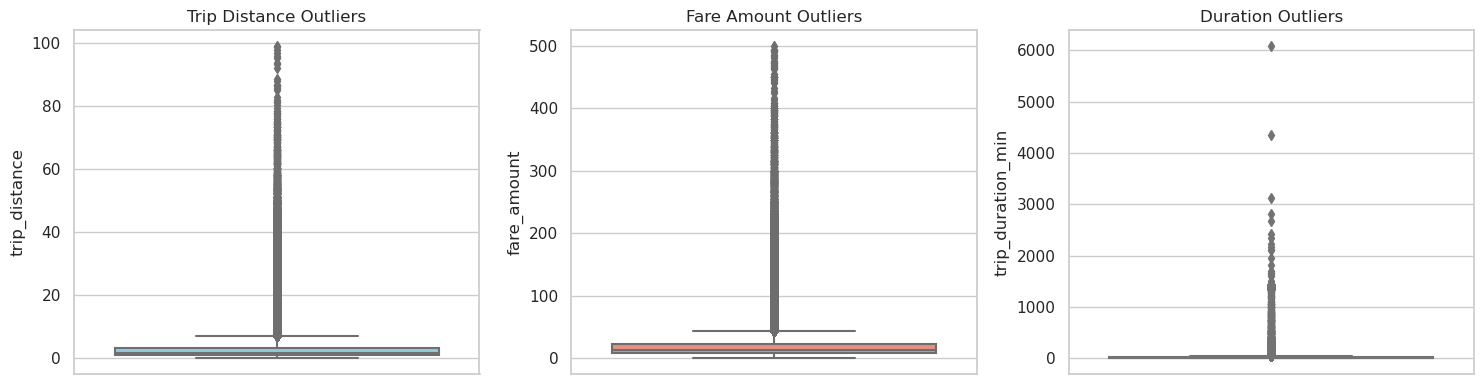

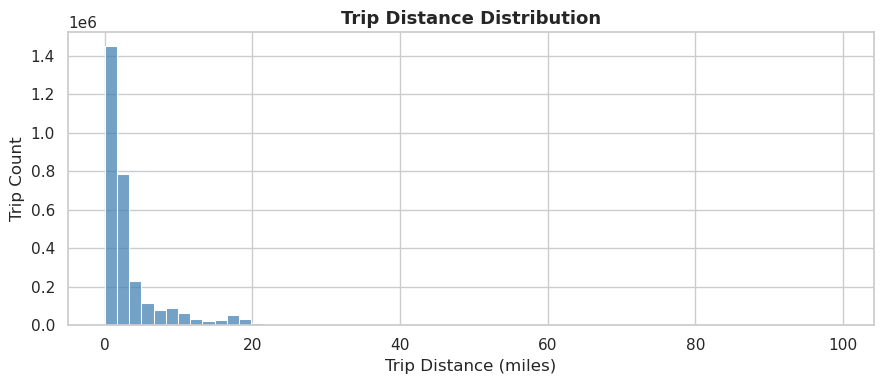

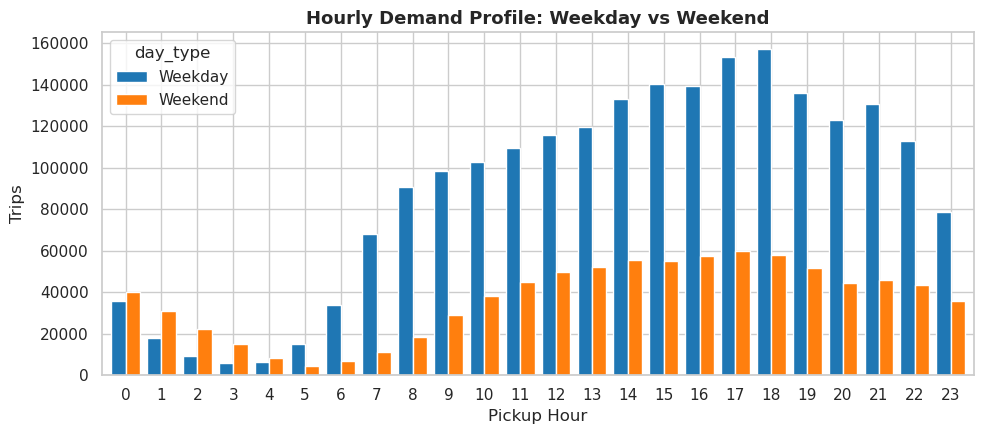

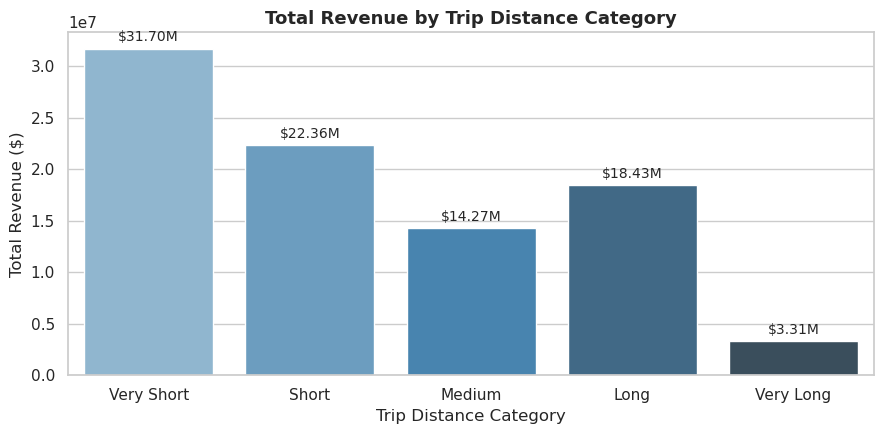

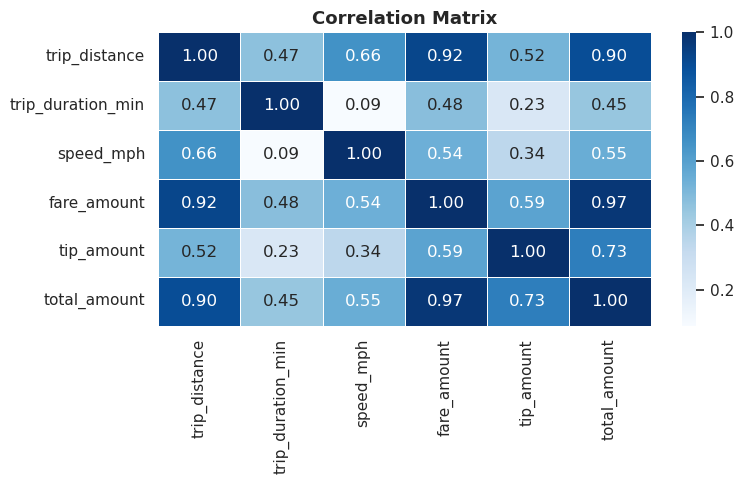

In [11]:
# ==============================================================================
# SECTION 6: ESSENTIAL EDA 
# ==============================================================================
# 6.1 Outlier Verification
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=df, y="trip_distance", ax=axes[0], color="skyblue")
axes[0].set_title("Trip Distance Outliers")

sns.boxplot(data=df, y="fare_amount", ax=axes[1], color="salmon")
axes[1].set_title("Fare Amount Outliers")

sns.boxplot(
    data=df, y="trip_duration_min", ax=axes[2], color="lightgreen"
)
axes[2].set_title("Duration Outliers")
plt.show()


# 6.2 Distance Distribution
plt.figure(figsize=(9, 4))
sns.histplot(
    data=df, x="trip_distance", bins=60, color="steelblue", kde=False
)
plt.title("Trip Distance Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Trip Count")
plt.show()


# 6.3 Weekday vs Weekend Hourly Demand Profile
fig, ax = plt.subplots(figsize=(10, 4.5))
df.groupby(["pickup_hour", "day_type"]).size().unstack().plot(
    kind="bar", ax=ax, width=0.8, color=["#1f77b4", "#ff7f0e"]
)
ax.set_title(
    "Hourly Demand Profile: Weekday vs Weekend", fontsize=13, fontweight="bold"
)
ax.set_xlabel("Pickup Hour")
ax.set_ylabel("Trips")
plt.xticks(rotation=0)
plt.show()


# 6.4 Total Revenue by Trip Distance Category 
plt.figure(figsize=(9, 4.5))
revenue_by_cat = (
    df.groupby("trip_category", observed=False)
    .agg(total_revenue=("total_amount", "sum"))
    .reset_index()
)

ax = sns.barplot(
    data=revenue_by_cat,
    x="trip_category",
    y="total_revenue",
    palette="Blues_d",
)

plt.title("Total Revenue by Trip Distance Category", fontsize=13, fontweight="bold")
plt.xlabel("Trip Distance Category")
plt.ylabel("Total Revenue ($)")

# Add labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"${height/1e6:.2f}M",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 3),
            textcoords="offset points",
        )

plt.show()


# 6.5 Heatmap Correlation
plt.figure(figsize=(8, 5))
corr_cols = [
    "trip_distance",
    "trip_duration_min",
    "speed_mph",
    "fare_amount",
    "tip_amount",
    "total_amount",
]
sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
)
plt.title("Correlation Matrix", fontsize=13, fontweight="bold")
plt.show()


### STATISTICAL EXPLORATION (BUSINESS QUESTIONS)


SECTION 7: STATISTICAL EXPLORATION (BUSINESS QUESTIONS)


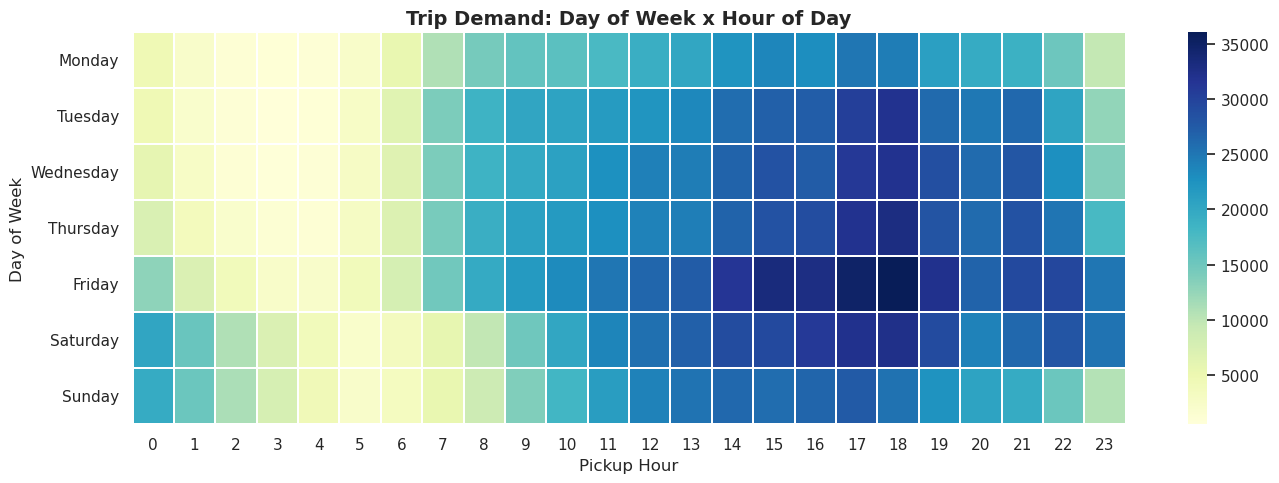


--- BQ1: Peak Demand Windows ---
Peak demand hour: 18:00
Peak demand day: Friday

---BQ2: REVENUE BY TRIP DISTANCE CATEGORY ---
trip_category  avg_revenue  total_revenue  trip_count
   Very Short       18.467    31695554.78     1716292
        Short       29.672    22359433.53      753553
       Medium       50.092    14268883.72      284856
         Long       80.105    18429829.80      230072
    Very Long      114.750     3313294.78       28874


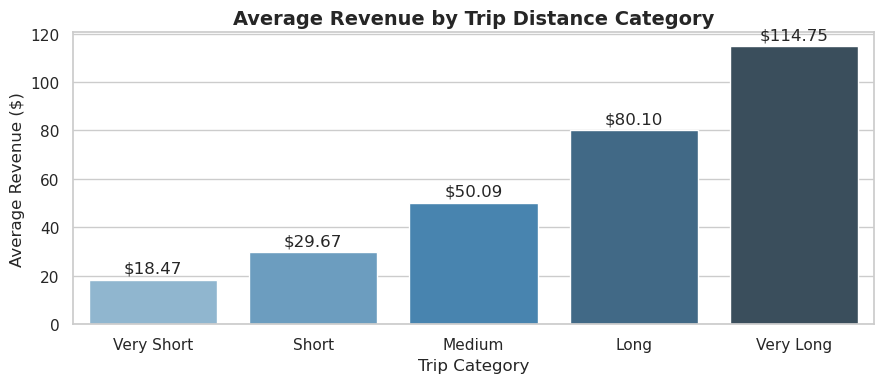


--- CORRELATION WITH TOTAL REVENUE ---
total_amount         1.00
trip_distance        0.90
speed_mph            0.55
trip_duration_min    0.45
tip_pct             -0.01
Name: total_amount, dtype: float64

---BQ3. CUSTOMER BEHAVIOR: WEEKDAY VS WEEKEND ---
day_type  avg_tip_pct  avg_passengers  avg_fare
 Weekday        21.70            1.21     20.44
 Weekend        21.15            1.34     19.63


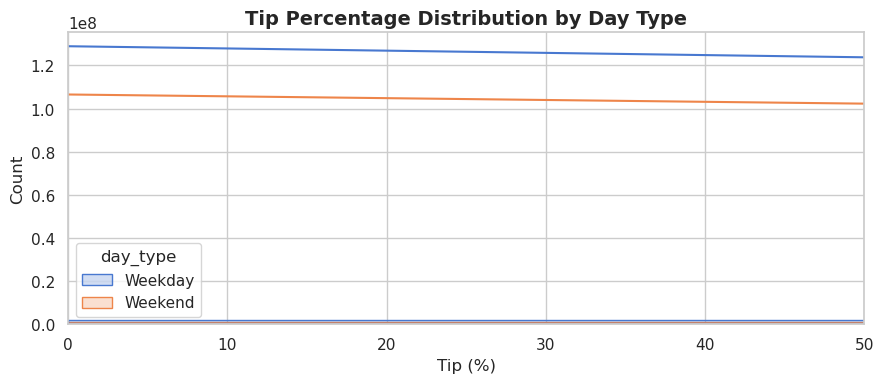


--- PAYMENT METHOD SHARE (%) ---
payment_method
Credit card    87.80
Cash           11.60
Dispute         0.37
No charge       0.23
Name: proportion, dtype: float64

---BQ4: TOP 10 PICKUP ZONES BY DEMAND ---
                 Pickup Zone  Trips
       Upper East Side South 174442
       Upper East Side North 148070
                 JFK Airport 140637
              Midtown Center 138753
                Midtown East 106414
         Lincoln Square East 102867
           LaGuardia Airport 101761
Penn Station/Madison Sq West  99691
   Times Sq/Theatre District  93302
               Midtown North  86856


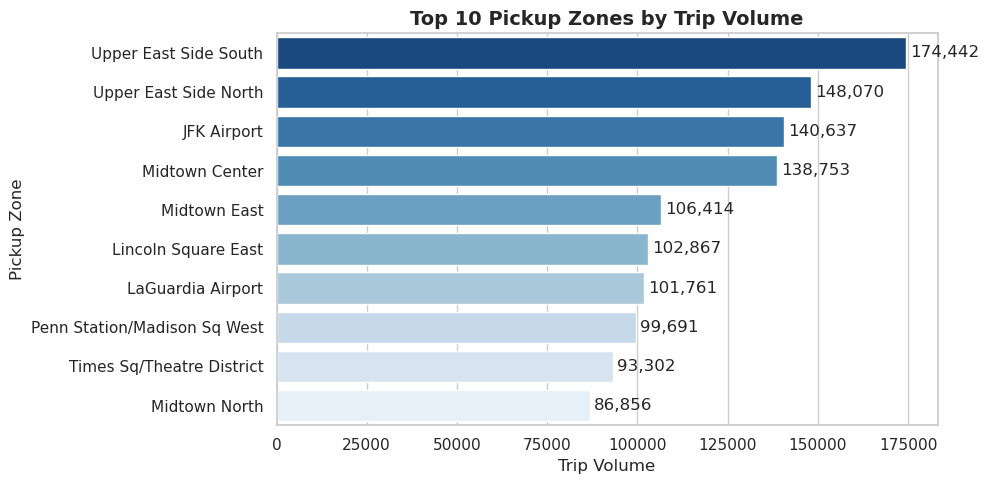


--- DEMAND SHARE BY BOROUGH (%) ---
pickup_Borough
Manhattan        87.39
Queens            9.51
Brooklyn          2.19
Bronx             0.75
Unknown           0.14
Outside NYC       0.02
Staten Island     0.00
EWR               0.00
Name: proportion, dtype: float64

---BQ5: AIRPORT VS NON-AIRPORT TRIP PROFITABILITY ---
  trip_type  avg_fare  avg_total  avg_revenue_per_mile  avg_tip_pct  avg_distance  trip_count
    Airport     71.03      96.53                 14.71        17.53         17.37      100900
Non-Airport     18.44      27.58                 15.36        21.68          2.96     2912747


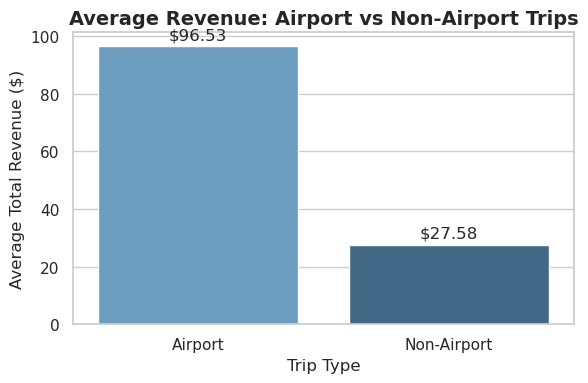


---BQ6: OPERATIONAL EFFICIENCY BY TIME OF DAY ---
time_of_day  avg_speed  avg_duration  avg_revenue_per_mile  trip_count
  Afternoon       8.50         21.97                 16.18      918144
    Evening       9.56         17.77                 16.47      783828
    Morning      10.42         19.89                 14.21      672032
      Night      12.39         15.87                 13.92      639643


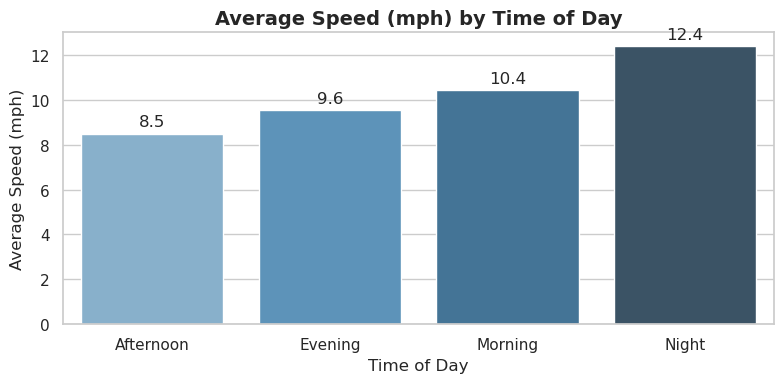


---BQ7: TOP 10 ROUTES BY TOTAL REVENUE ---
              pickup_Zone              dropoff_Zone  total_revenue  trip_count
              JFK Airport            Outside of NYC      768564.28        6226
              JFK Airport Times Sq/Theatre District      587466.55        6053
        LaGuardia Airport Times Sq/Theatre District      505451.16        6009
    Upper East Side South     Upper East Side North      449461.98       27689
    Upper East Side North     Upper East Side South      387797.89       23271
        LaGuardia Airport            Midtown Center      329917.76        4108
              JFK Airport             Midtown South      313113.26        3190
              JFK Airport            Midtown Center      295553.23        3033
Times Sq/Theatre District         LaGuardia Airport      277740.40        3358
              JFK Airport              Clinton East      268357.03        2774

---BQ8: VARIABLES RANKED BY CORRELATION STRENGTH WITH REVENUE ---
trip_distance       

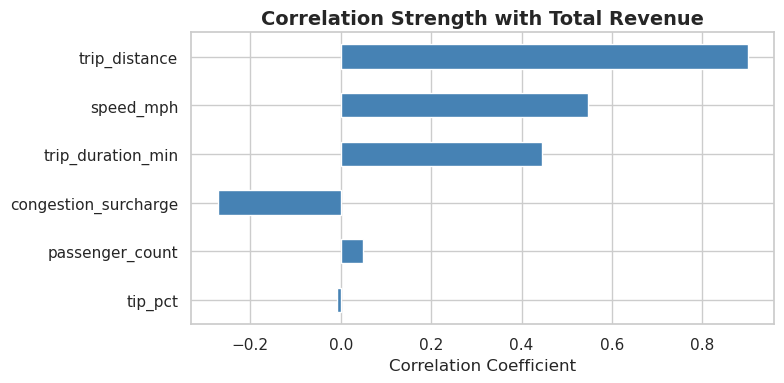


---BQ9: RUSH HOUR VS NON-RUSH HOUR ---
rush_hour  avg_speed  avg_duration  avg_fare  avg_revenue_per_mile  avg_tip_pct
       No      10.37         18.84     20.35                 15.05        21.40
      Yes       9.29         19.74     19.86                 15.97        21.86


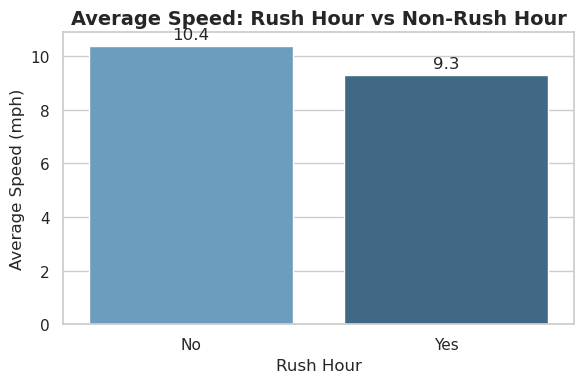

In [12]:
# ------------------------------------------------------------------------------
# SECTION 7: STATISTICAL EXPLORATION (BUSINESS QUESTIONS)
# ------------------------------------------------------------------------------

print("\n" + "=" * 50)
print("SECTION 7: STATISTICAL EXPLORATION (BUSINESS QUESTIONS)")
print("=" * 50)

# ------------------------------------------------------------------------------
# BQ1: When is taxi demand highest?
# ------------------------------------------------------------------------------
demand_heatmap = (
    df.groupby(["pickup_day", "pickup_hour"]).size().reset_index(name="trip_count")
    .pivot(index="pickup_day", columns="pickup_hour", values="trip_count")
    .reindex(
        [
            "Monday",
            "Tuesday",
            "Wednesday",
            "Thursday",
            "Friday",
            "Saturday",
            "Sunday",
        ]
    )
)

plt.figure(figsize=(14, 5))
sns.heatmap(demand_heatmap, cmap="YlGnBu", linewidths=0.3, annot=False)
plt.title(
    "Trip Demand: Day of Week x Hour of Day", fontsize=14, fontweight="bold"
)
plt.xlabel("Pickup Hour")
plt.ylabel("Day of Week")
plt.show()

print("\n--- BQ1: Peak Demand Windows ---")
peak_hour = df["pickup_hour"].value_counts().idxmax()
peak_day = df["pickup_day"].value_counts().idxmax()
print(f"Peak demand hour: {peak_hour}:00")
print(f"Peak demand day: {peak_day}")


# ------------------------------------------------------------------------------
# BQ2: What drives revenue?
# ------------------------------------------------------------------------------
revenue_drivers = (
    df.groupby("trip_category", observed=True)
    .agg(
        avg_revenue=("total_amount", "mean"),
        total_revenue=("total_amount", "sum"),
        trip_count=("total_amount", "count"),
    )
    .reset_index()
)
print("\n---BQ2: REVENUE BY TRIP DISTANCE CATEGORY ---")
print(revenue_drivers.round(3).to_string(index=False))


plt.figure(figsize=(9, 4))
ax = sns.barplot(
    data=revenue_drivers,
    x="trip_category",
    y="avg_revenue",
    palette="Blues_d",
)
plt.title(
    "Average Revenue by Trip Distance Category", fontsize=14, fontweight="bold"
)
plt.xlabel("Trip Category")
plt.ylabel("Average Revenue ($)")
for p in ax.patches:
    ax.annotate(
        f"${p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
    )
plt.show()

revenue_corr = (
    df[
        [
            "total_amount",
            "trip_distance",
            "trip_duration_min",
            "speed_mph",
            "tip_pct",
        ]
    ]
    .corr()["total_amount"]
    .sort_values(ascending=False)
)
print("\n--- CORRELATION WITH TOTAL REVENUE ---")
print(revenue_corr.round(2))


# ------------------------------------------------------------------------------
# BQ3: How do customers behave?
# ------------------------------------------------------------------------------
behavior_summary = (
    df.groupby("day_type")
    .agg(
        avg_tip_pct=("tip_pct", "mean"),
        avg_passengers=("passenger_count", "mean"),
        avg_fare=("fare_amount", "mean"),
    )
    .reset_index()
)
print("\n---BQ3. CUSTOMER BEHAVIOR: WEEKDAY VS WEEKEND ---")
print(behavior_summary.round(2).to_string(index=False))


plt.figure(figsize=(9, 4))
sns.histplot(
    data=df, x="tip_pct", bins=50, hue="day_type", kde=True, element="step"
)
plt.title(
    "Tip Percentage Distribution by Day Type", fontsize=14, fontweight="bold"
)
plt.xlabel("Tip (%)")
plt.xlim(0, 50)
plt.show()

payment_share = (
    df["payment_method"].value_counts(normalize=True).mul(100).round(2)
)
print("\n--- PAYMENT METHOD SHARE (%) ---")
print(payment_share)


# ------------------------------------------------------------------------------
# BQ4: Which locations generate the highest demand?
# ------------------------------------------------------------------------------
top_pickup_zones = df["pickup_Zone"].value_counts().head(10).reset_index()
top_pickup_zones.columns = ["Pickup Zone", "Trips"]
print("\n---BQ4: TOP 10 PICKUP ZONES BY DEMAND ---")
print(top_pickup_zones.to_string(index=False))

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=top_pickup_zones, x="Trips", y="Pickup Zone", palette="Blues_r"
)
plt.title(
    "Top 10 Pickup Zones by Trip Volume", fontsize=14, fontweight="bold"
)
plt.xlabel("Trip Volume")
plt.ylabel("Pickup Zone")
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_width()):,}",
        (p.get_width(), p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(3, 0),
        textcoords="offset points",
    )
plt.show()

borough_demand = (
    df["pickup_Borough"].value_counts(normalize=True).mul(100).round(2)
)
print("\n--- DEMAND SHARE BY BOROUGH (%) ---")
print(borough_demand)


# ------------------------------------------------------------------------------
# BQ5: Are airport trips more profitable?
# ------------------------------------------------------------------------------
df["trip_type"] = np.where(
    df["ratecode_name"].isin(["JFK", "Newark"]), "Airport", "Non-Airport"
)

airport_profitability = (
    df.groupby("trip_type")
    .agg(
        avg_fare=("fare_amount", "mean"),
        avg_total=("total_amount", "mean"),
        avg_revenue_per_mile=("revenue_per_mile", "mean"),
        avg_tip_pct=("tip_pct", "mean"),
        avg_distance=("trip_distance", "mean"),
        trip_count=("total_amount", "count"),
    )
    .reset_index()
)
print("\n---BQ5: AIRPORT VS NON-AIRPORT TRIP PROFITABILITY ---")
print(airport_profitability.round(2).to_string(index=False))


# plot the chart
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=airport_profitability, x="trip_type", y="avg_total", palette="Blues_d"
)
plt.title(
    "Average Revenue: Airport vs Non-Airport Trips",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Trip Type")
plt.ylabel("Average Total Revenue ($)")
for p in ax.patches:
    ax.annotate(
        f"${p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
    )
plt.show()


# ------------------------------------------------------------------------------
# BQ6: How efficient are taxi operations?
# ------------------------------------------------------------------------------
efficiency_by_time = (
    df.groupby("time_of_day")
    .agg(
        avg_speed=("speed_mph", "mean"),
        avg_duration=("trip_duration_min", "mean"),
        avg_revenue_per_mile=("revenue_per_mile", "mean"),
        trip_count=("total_amount", "count"),
    )
    .reset_index()
)
print("\n---BQ6: OPERATIONAL EFFICIENCY BY TIME OF DAY ---")
print(efficiency_by_time.round(2).to_string(index=False))

# plot the chart
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=efficiency_by_time, x="time_of_day", y="avg_speed", palette="Blues_d"
)
plt.title("Average Speed (mph) by Time of Day", fontsize=14, fontweight="bold")
plt.xlabel("Time of Day")
plt.ylabel("Average Speed (mph)")
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
    )
plt.show()


# ------------------------------------------------------------------------------
# BQ7: Which routes generate the most revenue?
# ------------------------------------------------------------------------------
top_routes_revenue = (
    df.groupby(["pickup_Zone", "dropoff_Zone"])
    .agg(
        total_revenue=("total_amount", "sum"),
        trip_count=("total_amount", "count"),
    )
    .reset_index()
    .sort_values(by="total_revenue", ascending=False)
    .head(10)
)
print("\n---BQ7: TOP 10 ROUTES BY TOTAL REVENUE ---")
print(top_routes_revenue.to_string(index=False))


# ------------------------------------------------------------------------------
# BQ8: Which variables influence revenue?
# ------------------------------------------------------------------------------
influence_vars = [
    "trip_distance",
    "trip_duration_min",
    "speed_mph",
    "tip_pct",
    "passenger_count",
    "congestion_surcharge",
]
influence_corr = (
    df[influence_vars + ["total_amount"]]
    .corr()["total_amount"]
    .drop("total_amount")
    .sort_values(key=abs, ascending=False)
)
print("\n---BQ8: VARIABLES RANKED BY CORRELATION STRENGTH WITH REVENUE ---")
print(influence_corr.round(3))


plt.figure(figsize=(8, 4))
influence_corr.plot(kind="barh", color="steelblue")
plt.title(
    "Correlation Strength with Total Revenue", fontsize=14, fontweight="bold"
)
plt.xlabel("Correlation Coefficient")
plt.gca().invert_yaxis()
plt.show()


# ------------------------------------------------------------------------------
# BQ9: What is the effect of rush hour?
# ------------------------------------------------------------------------------
rush_hour_effect = (
    df.groupby("rush_hour")
    .agg(
        avg_speed=("speed_mph", "mean"),
        avg_duration=("trip_duration_min", "mean"),
        avg_fare=("fare_amount", "mean"),
        avg_revenue_per_mile=("revenue_per_mile", "mean"),
        avg_tip_pct=("tip_pct", "mean"),
    )
    .reset_index()
)
print("\n---BQ9: RUSH HOUR VS NON-RUSH HOUR ---")
print(rush_hour_effect.round(2).to_string(index=False))


plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=rush_hour_effect, x="rush_hour", y="avg_speed", palette="Blues_d"
)
plt.title(
    "Average Speed: Rush Hour vs Non-Rush Hour", fontsize=14, fontweight="bold"
)
plt.xlabel("Rush Hour")
plt.ylabel("Average Speed (mph)")
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
    )
plt.show()


### STATISTICAL EXPLORATION

In [13]:
# ==============================================================================
# SECTION 8: STATISTICAL EXPLORATION
# ==============================================================================

print("\n" + "=" * 50)
print("SECTION 8: STATISTICAL EXPLORATION")
print("=" * 50)

# 8.1 Weekday vs Weekend tip percentage — Independent samples t-test
weekday_tips = df.loc[df["day_type"] == "Weekday", "tip_pct"].dropna()
weekend_tips = df.loc[df["day_type"] == "Weekend", "tip_pct"].dropna()
t_stat, p_val = stats.ttest_ind(weekday_tips, weekend_tips, equal_var=False)
print("\n--- T-TEST: TIP % (WEEKDAY VS WEEKEND) ---")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_val:.5f}")
print("Significant difference" if p_val < 0.05 else "No significant difference")


# 8.2 Fare amount across trip categories — ANOVA
fare_groups = [
    df.loc[df["trip_category"] == cat, "fare_amount"].dropna()
    for cat in df["trip_category"].cat.categories
]
f_stat, p_val_anova = stats.f_oneway(*fare_groups)
print("\n--- ANOVA: FARE AMOUNT ACROSS TRIP CATEGORIES ---")
print(f"F-statistic = {f_stat:.3f}, p-value = {p_val_anova:.5f}")
print(
    "Significant difference across categories"
    if p_val_anova < 0.05
    else "No significant difference"
)

# 8.3 Rush hour vs non-rush hour speed — Independent samples t-test
rush_speed = df.loc[df["rush_hour"] == "Yes", "speed_mph"].dropna()
non_rush_speed = df.loc[df["rush_hour"] == "No", "speed_mph"].dropna()
t_stat2, p_val2 = stats.ttest_ind(rush_speed, non_rush_speed, equal_var=False)
print("\n--- T-TEST: SPEED (RUSH HOUR VS NON-RUSH HOUR) ---")
print(f"t-statistic = {t_stat2:.3f}, p-value = {p_val2:.5f}")
print(
    "Significant difference" if p_val2 < 0.05 else "No significant difference"
)


# 8.4 Payment method vs Day type — Chi-square
contingency = pd.crosstab(df["payment_method"], df["day_type"])
chi2, p_val3, dof, expected = stats.chi2_contingency(contingency)
print("\n--- CHI-SQUARE: PAYMENT METHOD x DAY TYPE ---")
print(f"chi2 = {chi2:.3f}, p-value = {p_val3:.5f}, dof = {dof}")
print(
    "Payment method is associated with day type"
    if p_val3 < 0.05
    else "No significant association"
)


# 8.5 Trip distance vs fare amount — Pearson correlation
r_val, p_val4 = stats.pearsonr(df["trip_distance"], df["fare_amount"])
print("\n--- PEARSON CORRELATION: TRIP DISTANCE VS FARE AMOUNT ---")
print(f"r = {r_val:.3f}, p-value = {p_val4:.2e}")


# 8.6 Airport vs non-airport revenue per mile - T-test
airport_rpm = df.loc[df["trip_type"] == "Airport", "revenue_per_mile"].dropna()
non_airport_rpm = df.loc[
    df["trip_type"] == "Non-Airport", "revenue_per_mile"
].dropna()
t_stat3, p_val5 = stats.ttest_ind(
    airport_rpm, non_airport_rpm, equal_var=False
)
print("\n--- T-TEST: REVENUE PER MILE (AIRPORT VS NON-AIRPORT) ---")
print(f"t-statistic = {t_stat3:.3f}, p-value = {p_val5:.5f}")
print(
    "Significant difference" if p_val5 < 0.05 else "No significant difference"
)


SECTION 8: STATISTICAL EXPLORATION

--- T-TEST: TIP % (WEEKDAY VS WEEKEND) ---
t-statistic = 4.160, p-value = 0.00003
Significant difference

--- ANOVA: FARE AMOUNT ACROSS TRIP CATEGORIES ---
F-statistic = 2674943.320, p-value = 0.00000
Significant difference across categories

--- T-TEST: SPEED (RUSH HOUR VS NON-RUSH HOUR) ---
t-statistic = -155.500, p-value = 0.00000
Significant difference

--- CHI-SQUARE: PAYMENT METHOD x DAY TYPE ---
chi2 = 1117.946, p-value = 0.00000, dof = 3
Payment method is associated with day type

--- PEARSON CORRELATION: TRIP DISTANCE VS FARE AMOUNT ---
r = 0.924, p-value = 0.00e+00

--- T-TEST: REVENUE PER MILE (AIRPORT VS NON-AIRPORT) ---
t-statistic = -1.160, p-value = 0.24615
No significant difference


In [14]:
# ==============================================================================
# SECTION 9: EXPORT CLEANED DATA
# ==============================================================================
csv_output = r"C:\Users\hp\Desktop\folder for data output\NYC_Yellow_Trip.csv"
df.to_csv(csv_output, index=False)
print(f"\n Cleaned data saved successfully to: {csv_output}")


 Cleaned data saved successfully to: C:\Users\hp\Desktop\folder for data output\NYC_Yellow_Trip.csv
